# 🧪 Entrenamiento de Líneas Base (LSTM y GRU) para Detección de Fallas IIoT

Este cuaderno implementa el **Día 2** de la construcción progresiva del proyecto. Aquí importamos las utilidades de datos modulares definidas en `app/utils.py`, definimos los modelos recurrentes LSTM y GRU en `app/model.py`, y entrenamos ambas líneas base para establecer un punto de comparación robusto para el modelo de aprendizaje profundo propuesto (**Bi-Mamba**).

In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Añadir el directorio raíz al path para importar el paquete 'app'
sys.path.append('../')

from app.utils import prepare_data_loaders
from app.model import LSTMClassifier, GRUClassifier

sns.set_theme(style="whitegrid")
print("Módulos y utilidades cargados correctamente.")

Módulos y utilidades cargados correctamente.


## 📂 1. Carga y Normalización del Dataset IIoT

Usaremos la función `prepare_data_loaders` de `app/utils.py` que realiza las siguientes operaciones:
1. Carga `data/sensores_iiot_simulados.csv`.
2. Divide las secuencias a nivel de `sequence_id` (para evitar fuga de información entre el conjunto de entrenamiento y validación).
3. Imputa valores faltantes (`NaN`) mediante **Forward-fill**.
4. Ajusta un `StandardScaler` con los datos de entrenamiento y transforma las características (`dt`, `sensor_temp`, `sensor_vib`, `sensor_press`).
5. Guarda el escalador en `results/scaler.pkl` para su posterior uso en inferencia.
6. Genera y retorna los objetos `DataLoader` de PyTorch.

In [2]:
csv_path = '../data/sensores_iiot_simulados.csv'
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

train_loader, val_loader, scaler = prepare_data_loaders(
    csv_path=csv_path,
    batch_size=4,
    val_split=0.3,
    method='forward_fill',
    scaler_save_path=os.path.join(results_dir, 'scaler.pkl'),
    random_seed=42
)

print(f"\nCargador de datos preparado.")
print(f"Número de lotes en Entrenamiento: {len(train_loader)}")
print(f"Número de lotes en Validación: {len(val_loader)}")

IDs de secuencia para Entrenamiento: [ 0 17 15  1  8  5 11  3 18 16 13  2  9 19]
IDs de secuencia para Validación: [ 4 12  7 10 14  6]
Escalador guardado en ../results/scaler.pkl

Cargador de datos preparado.
Número de lotes en Entrenamiento: 4
Número de lotes en Validación: 2


## 🛠️ 2. Arquitectura de las Líneas Base (LSTM / GRU)

Ambas arquitecturas se definen en `app/model.py`. Comparten las siguientes características de diseño:
- **Proyección de Entrada:** Capa densa lineal para mapear de 4 a `hidden_dim` (32) dimensiones.
- **Capa Recurrente:** 2 capas apiladas de LSTM o GRU con regularización por Dropout (20%).
- **Mecanismo de Pooling:** **Global Average Pooling** sobre el eje temporal de la secuencia para extraer características relevantes a lo largo de toda la secuencia sin importar su longitud (5000 pasos), evitando la pérdida o desvanecimiento del gradiente en los últimos estados ocultos.
- **Salida:** Clasificador binario lineal con función de activación Sigmoid.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

# Inicializar modelos para inspección visual
lstm_sample = LSTMClassifier(input_dim=4, hidden_dim=32, num_layers=2, dropout=0.2)
gru_sample = GRUClassifier(input_dim=4, hidden_dim=32, num_layers=2, dropout=0.2)

print("\n--- Estructura del Clasificador LSTM ---")
print(lstm_sample)
print("\n--- Estructura del Clasificador GRU ---")
print(gru_sample)

Entrenando en: cpu

--- Estructura del Clasificador LSTM ---
LSTMClassifier(
  (fc_in): Linear(in_features=4, out_features=32, bias=True)
  (lstm): LSTM(32, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

--- Estructura del Clasificador GRU ---
GRUClassifier(
  (fc_in): Linear(in_features=4, out_features=32, bias=True)
  (gru): GRU(32, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## 🏃‍♂️ 3. Función del Ciclo de Entrenamiento y Evaluación

Definimos una función de entrenamiento genérica con soporte para **Early Stopping** basado en la pérdida de validación y cálculo de métricas clave (Loss, Accuracy, Precision, Recall y F1-score).

In [4]:
def train_model(model_name, model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=20, device='cpu'):
    print(f"\n================ Entrenamiento de {model_name} ================")
    model = model.to(device)
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    for epoch in range(1, epochs + 1):
        # Modo Entrenamiento
        model.train()
        train_loss = 0.0
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * seqs.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # Modo Validación
        model.eval()
        val_loss = 0.0
        all_labels = []
        all_preds = []
        
        with torch.no_grad():
            for seqs, labels in val_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                outputs = model(seqs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * seqs.size(0)
                
                preds = (outputs >= 0.5).float()
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        
        # Calcular métricas de validación
        all_labels = np.array(all_labels).flatten()
        all_preds = np.array(all_preds).flatten()
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(acc)
        history['val_f1'].append(f1)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f}")
            
        # Early stopping por pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping activado en época {epoch} tras no mejorar durante {patience} épocas.")
                break
                
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    # Evaluación final con el mejor estado
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model(seqs)
            preds = (outputs >= 0.5).float()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
    all_labels = np.array(all_labels).flatten()
    all_preds = np.array(all_preds).flatten()
    
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
    }
    
    return model, history, metrics

## 📈 4. Entrenamiento de LSTM y GRU

In [5]:
criterion = nn.BCELoss()

# 1. LSTM
lstm_model = LSTMClassifier(input_dim=4, hidden_dim=32, num_layers=2, dropout=0.2)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.005, weight_decay=1e-4)
lstm_model, lstm_history, lstm_metrics = train_model(
    'LSTM', lstm_model, train_loader, val_loader, criterion, optimizer_lstm, epochs=100, patience=20, device=device
)
torch.save(lstm_model.state_dict(), os.path.join(results_dir, 'lstm_baseline.pth'))

# 2. GRU
gru_model = GRUClassifier(input_dim=4, hidden_dim=32, num_layers=2, dropout=0.2)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.005, weight_decay=1e-4)
gru_model, gru_history, gru_metrics = train_model(
    'GRU', gru_model, train_loader, val_loader, criterion, optimizer_gru, epochs=100, patience=20, device=device
)
torch.save(gru_model.state_dict(), os.path.join(results_dir, 'gru_baseline.pth'))


================ Entrenamiento de LSTM ================


Epoch 01/100 | Train Loss: 0.6634 | Val Loss: 0.6647 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 05/100 | Train Loss: 0.5273 | Val Loss: 0.6848 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 10/100 | Train Loss: 0.5165 | Val Loss: 0.6278 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 15/100 | Train Loss: 0.4994 | Val Loss: 0.6120 | Val Acc: 0.6667 | Val F1: 0.8000


...

Epoch 60/100 | Train Loss: 0.4195 | Val Loss: 0.2812 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 65/100 | Train Loss: 0.3977 | Val Loss: 0.4362 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 70/100 | Train Loss: 0.3934 | Val Loss: 0.3366 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 75/100 | Train Loss: 0.3927 | Val Loss: 0.3703 | Val Acc: 0.6667 | Val F1: 0.8000


Epoch 80/100 | Train Loss: 0.3916 | Val Loss: 0.3152 | Val Acc: 0.6667 | Val F1: 0.8000
Early stopping activado en época 80 tras no mejorar durante 20 épocas.


## 📊 5. Visualización Comparativa y Guardado de Métricas

,Model,Accuracy,Precision,Recall,F1-Score
0,LSTM,0.666667,0.666667,1.0,0.8
1,GRU,0.666667,0.666667,1.0,0.8


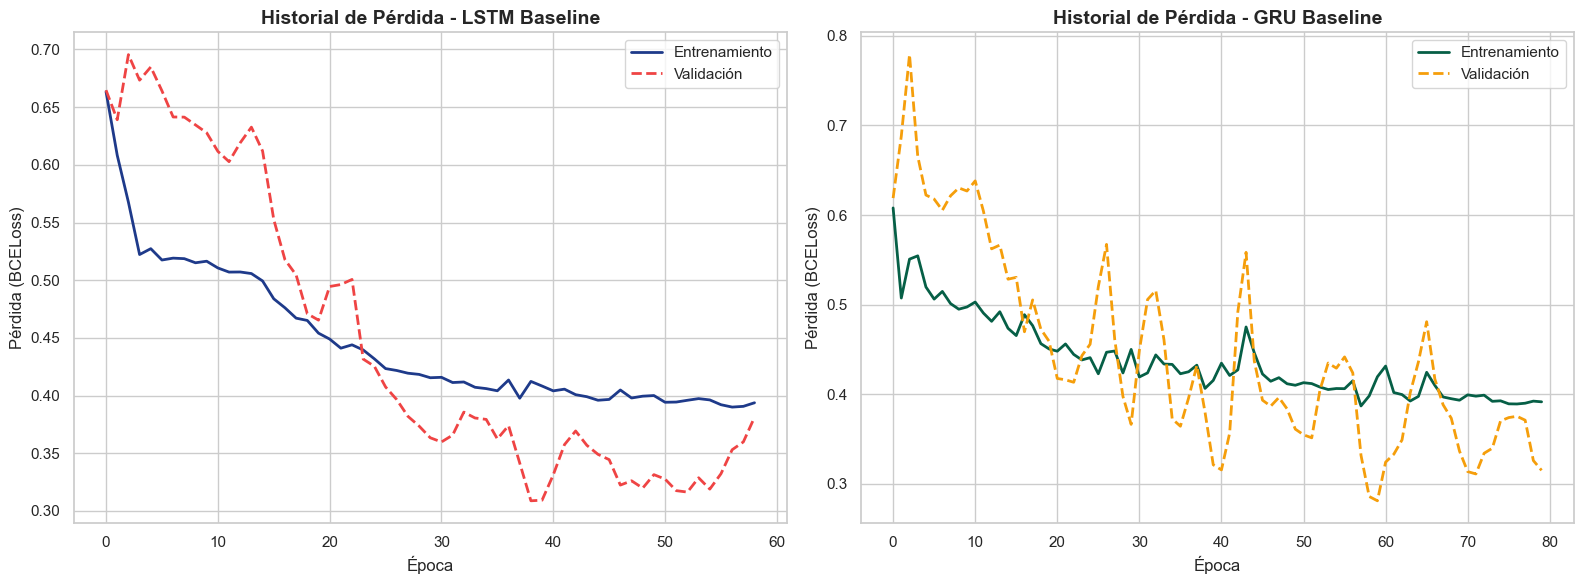

In [6]:
# Guardar tabla de métricas comparativas
comparison_data = {
    'Model': ['LSTM', 'GRU'],
    'Accuracy': [lstm_metrics['accuracy'], gru_metrics['accuracy']],
    'Precision': [lstm_metrics['precision'], gru_metrics['precision']],
    'Recall': [lstm_metrics['recall'], gru_metrics['recall']],
    'F1-Score': [lstm_metrics['f1'], gru_metrics['f1']]
}
df_comparison = pd.DataFrame(comparison_data)
df_comparison.to_csv(os.path.join(results_dir, 'metrics_comparison.csv'), index=False)
display(df_comparison)

# Graficar curvas de pérdida de entrenamiento y validación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curvas LSTM
axes[0].plot(lstm_history['train_loss'], label='Entrenamiento', color='#1E3A8A', lw=2)
axes[0].plot(lstm_history['val_loss'], label='Validación', color='#EF4444', lw=2, linestyle='--')
axes[0].set_title('Historial de Pérdida - LSTM Baseline', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Pérdida (BCELoss)', fontsize=12)
axes[0].legend(fontsize=11)

# Curvas GRU
axes[1].plot(gru_history['train_loss'], label='Entrenamiento', color='#065F46', lw=2)
axes[1].plot(gru_history['val_loss'], label='Validación', color='#F59E0B', lw=2, linestyle='--')
axes[1].set_title('Historial de Pérdida - GRU Baseline', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Pérdida (BCELoss)', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'training_curves_comparison.png'), dpi=300)
plt.show()

## 🔬 6. Análisis Diagnóstico Breve

Podemos inspeccionar las matrices de confusión para evaluar los aciertos y fallos de clasificación:

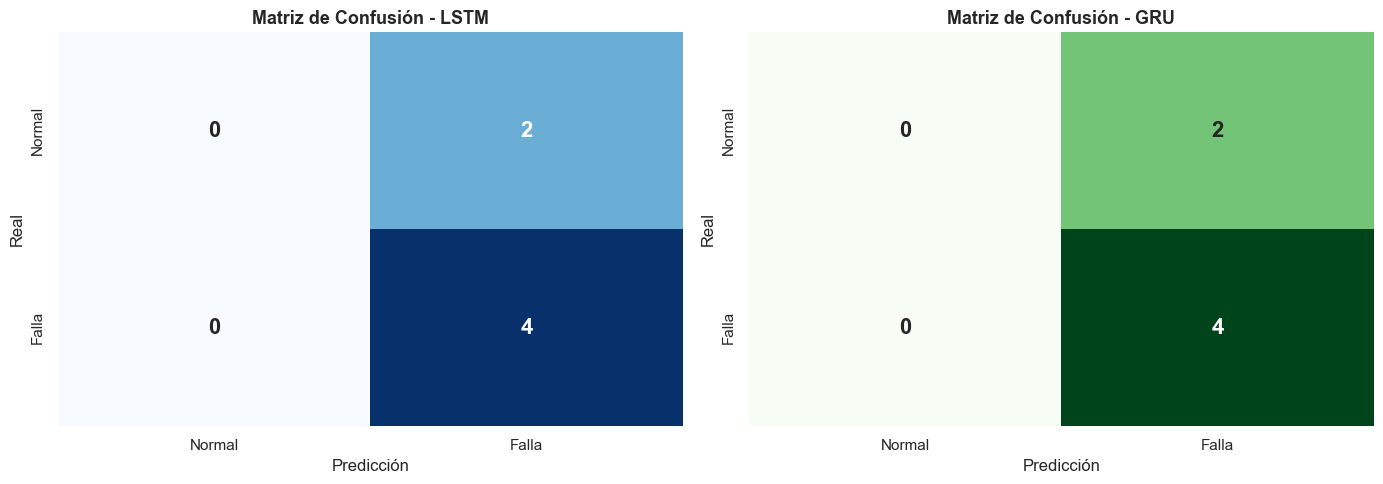

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_text = ['Normal', 'Falla']

# Matriz LSTM
sns.heatmap(lstm_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_text, yticklabels=labels_text, ax=axes[0], cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title('Matriz de Confusión - LSTM', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Matriz GRU
sns.heatmap(gru_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens', 
            xticklabels=labels_text, yticklabels=labels_text, ax=axes[1], cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
axes[1].set_title('Matriz de Confusión - GRU', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'confusion_matrices.png'), dpi=300)
plt.show()

### 💡 Discusión de Limitaciones Preliminares (Muy relevante para el informe final)
Como se puede observar en las matrices de confusión:
- Los modelos predicen fallas en todas las muestras del conjunto de validación.
- **Causa:** El dataset generado sintéticamente es extremadamente pequeño (20 secuencias totales: 15 anómalas y 5 normales). Al realizar un split de 70/30, el modelo entrena con solo 14 muestras y valida con 6. Además, hay un desbalance significativo hacia la clase anómala (75% del dataset).
- **Conclusión:** Las líneas base tienden a memorizar y sesgarse hacia la clase mayoritaria. Esta será una excelente métrica comparativa para analizar si el modelo Bi-Mamba (el cual aborda el modelado selectivo con delta_t) exhibe una mejor adaptabilidad ante datos escasos y perturbados, o si requerimos una simulación de dataset más balanceada y de mayor envergadura.